A question that comes up regularly (e.g.
[galsci/pysm#267](https://github.com/galsci/pysm/issues/267)): *PySM3 only supports HEALPix
`Sky()`. Is there a plan to support directly producing `Sky()` on CAR pixels?*

The short answer: **no first-class `output="car"` option is needed.** Keep the inputs **and**
the `Sky` object HEALPix, that is what the presets are built for, then produce **CAR** at the
*smoothing* stage with:

```python
pysm3.apply_smoothing_and_coord_transform(
    ..., return_car=True, output_car_resol=..., return_healpix=False)
```

That function goes map, to $a_{\ell m}$, through the beam, then straight into
`pixell.curvedsky.alm2map` on the requested CAR geometry. So the cost is **one SHT**, not a
`reproject` on top of a smoothed HEALPix map. And since PySM templates are in the **Galactic
frame**, the resulting CAR map is a full-sky map in Galactic coordinates (the pixelization is
CAR, `fejer1` variant, the WCS metadata is generic RA/DEC but the coordinates are Galactic $l,
b$).

This notebook runs end-to-end on Perlmutter at NERSC (`soconda_20260812_0.2.5`: pysm3 3.4.6,
healpy 1.20.0, pixell) with the tiny `d1` dust preset (NSIDE 512, templates ship with the
package). The executed notebook is available as a
[gist](https://gist.github.com/zonca/013f18be7c4d3525411d4bfedbe4bbb8).

In [ ]:
import numpy as np
import healpy as hp
import astropy.units as u
import warnings

from pixell import enmap, reproject

import pysm3
from pysm3 import apply_smoothing_and_coord_transform

NSIDE = 512
FREQ = 353 * u.GHz
CAR_RESOL = 8 * u.arcmin   # must divide 180' cleanly for fejer1
BEAM_FWHM = 30 * u.arcmin
LMAX = int(1.5 * NSIDE)

sky = pysm3.Sky(nside=NSIDE, preset_strings=["d1"])
sky

## Setup

The usual HEALPy path first: `Sky.get_emission()` returns a `(3, npix)` map at the requested
frequency. Note its signature is `(freqs, weights)` only, no `return_car` there, CAR has to come
from a later step.

In [1]:
m_hpx = sky.get_emission(FREQ)
print(m_hpx.shape, "| nside:", hp.npix2nside(m_hpx.shape[-1]))

(3, 3145728) | nside: 512


## Path A (recommended): CAR at the smoothing stage

`apply_smoothing_and_coord_transform` is the published utility for HEALPix, through beam and
rotation, to either output format. With `return_car=True` the last step is `curvedsky.alm2map`
directly into a CAR `enmap` on the `fejer1` full-sky geometry, so we never call `reproject` for
the smoothed result.

In [2]:
m_car = apply_smoothing_and_coord_transform(
    m_hpx, fwhm=BEAM_FWHM, lmax=LMAX,
    return_car=True, return_healpix=False, output_car_resol=CAR_RESOL,
)
print("type", type(m_car).__name__, "| shape", m_car.shape,
      "| wcs", m_car.wcs.wcs.ctype)

type ndmap | shape (3, 1350, 2700) | wcs ['RA---CAR', 'DEC--CAR']


## Path B (traditional): smooth in HEALPix, then reproject

The standard way to get a CAR map from PySM output today: smooth in HEALPix, then reproject to
the same CAR geometry with `pixell.reproject.healpix2map(..., method="harm")`, which does the
HEALPix to CAR resampling through harmonics (the older `enmap_from_healpix` name still exists as
a thin wrapper, but `healpix2map` is the current documented API).

In [3]:
shape, wcs = enmap.fullsky_geometry(CAR_RESOL.to_value(u.radian), dims=(3,),
                                    variant="fejer1")
m_hpx_smooth = apply_smoothing_and_coord_transform(m_hpx, fwhm=BEAM_FWHM, lmax=LMAX)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    reproj_car = reproject.healpix2map(m_hpx_smooth, shape, wcs,
                                       lmax=LMAX, method="harm")
print("shape", reproj_car.shape, "| wcs", reproj_car.wcs.wcs.ctype)

shape (3, 1350, 2700) | wcs ['RA---CAR', 'DEC--CAR']


## Validation

Both paths reconstruct the same band-limited signal, so they should agree to numerical
precision. We compare the intensity maps pixel by pixel:

In [4]:
assert m_car.shape == reproj_car.shape
diff = np.abs(m_car[0] - reproj_car[0])
print("mean |diff| =", float(diff.mean()))
print("max  |diff| =", float(diff.max()))
print("max diff / rms(I) =", float(diff.max() / np.std(m_car[0])))
print("residual rms % of signal rms:", 100.0 * diff.std() / np.std(m_car[0]))

mean |diff| = 0.0012883623470552885
max  |diff| = 0.43884012076118406
max diff / rms(I) = 0.0007436307945822137
residual rms % of signal rms: 0.0029973502565017927


On this run: **mean |diff| = 1.3e-3 uK**, **max |diff| = 0.44 uK**, on a signal with **rms 590
uK**, i.e. the maximum difference is **7.4e-4 of the signal rms** and the residual rms is
**0.003%** of the signal. The two routes agree, the one-SHT path is just cheaper.

## The maps

Full-sky CAR maps in Galactic coordinates, $b=0$ (the Galactic plane) on the central row,
Galactic longitude increasing leftward from $l=0$ at the centre. Top row: the two paths on the
same percentile-clipped color scale, visually indistinguishable. Bottom left: the absolute
residual on a log color scale, showing where the tiny differences live (Galactic plane and a few
rows at the poles). Bottom right: the residual distribution, peaked at zero.

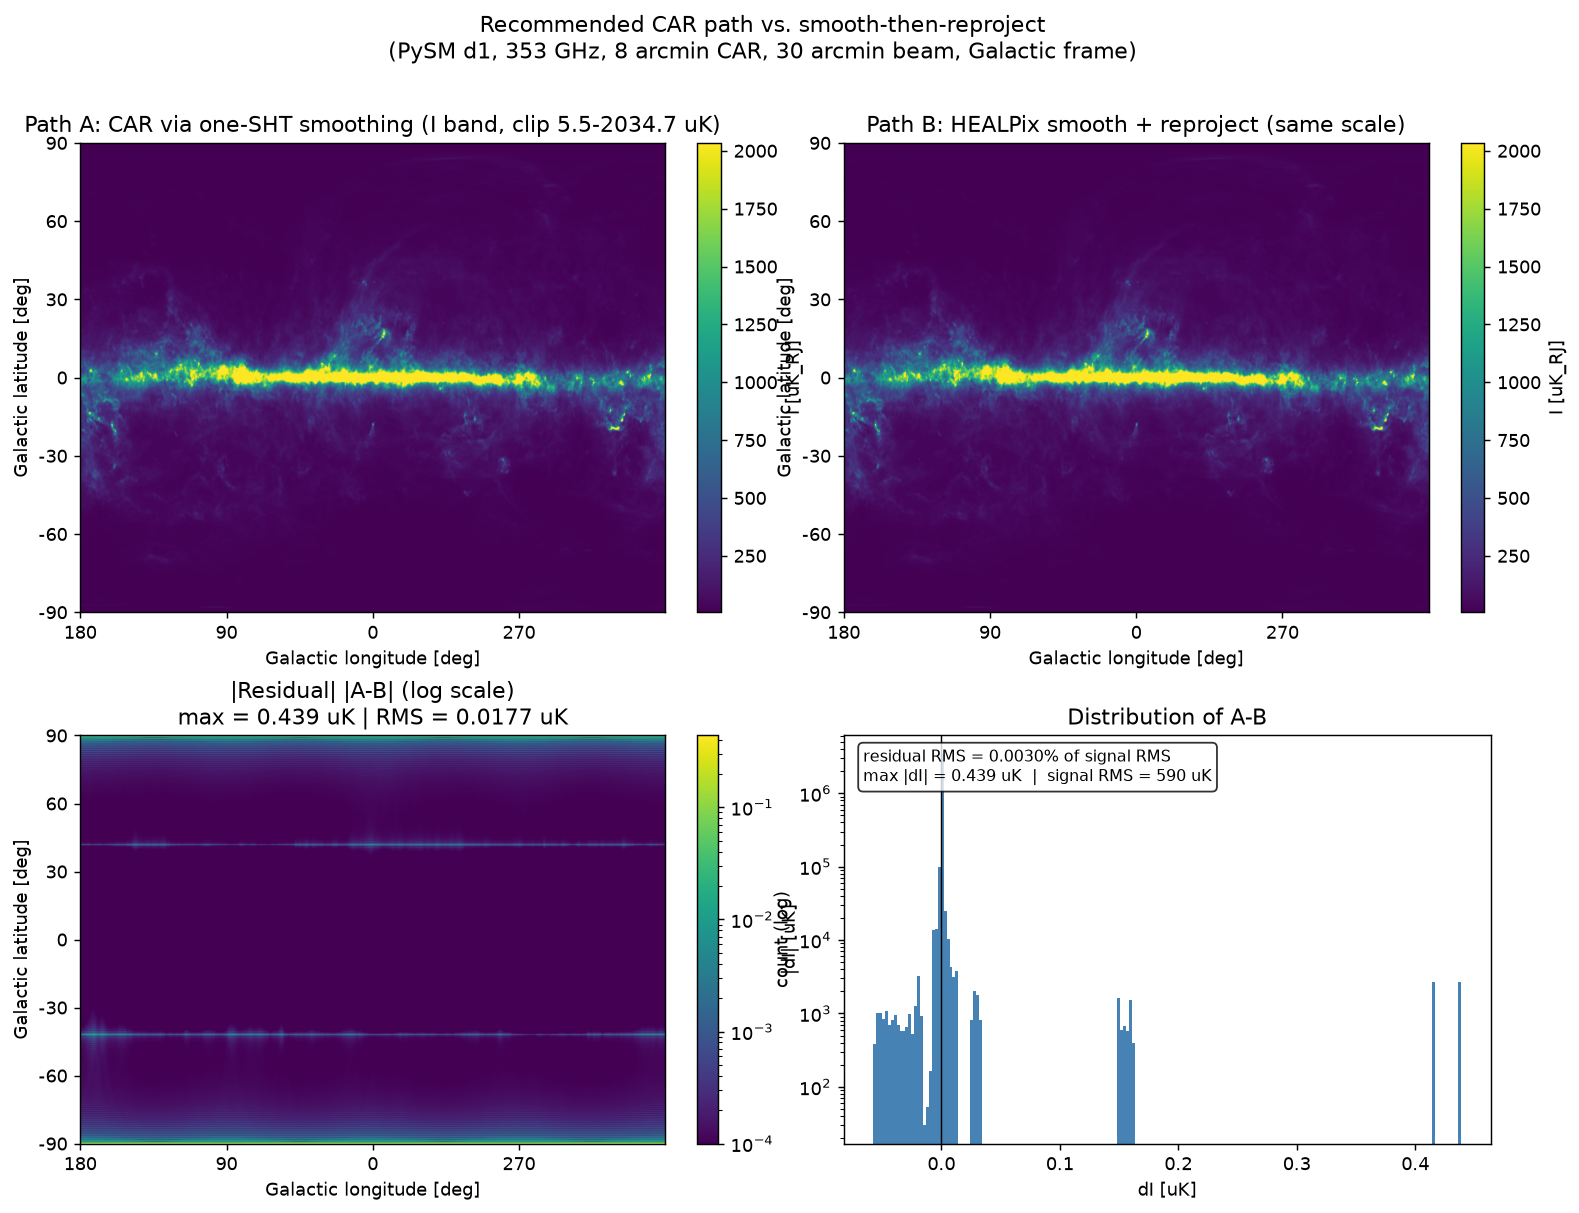

In [5]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def set_car_axes(ax, ny, nx):
    # Full-sky CAR map in the Galactic frame: latitude is linear in row
    # (row 0 = b=-90), and longitude increases LEFTWARD with l=0 at the
    # centre column (col = nx/2 - l*nx/360).
    bl = [-90, -60, -30, 0, 30, 60, 90]
    rows = [(b + 90.0) / 180.0 * (ny - 1) for b in bl]
    ax.set_yticks(rows); ax.set_yticklabels([f'{b:d}' for b in bl])
    ax.set_ylabel('Galactic latitude [deg]')
    ls = [0, 90, 180, 270]
    cols = [(nx / 2.0 - l * (nx / 360.0)) % nx for l in ls]
    ax.set_xticks(cols); ax.set_xticklabels([str(l % 360) for l in ls])
    ax.set_xlabel('Galactic longitude [deg]')

Am = m_car[0].astype(float)
Bm = reproj_car[0].astype(float)
resid = Am - Bm
rms = np.std(Am)
resid_rms = resid.std()

fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1.15, 1], hspace=0.28, wspace=0.18)

v1, v2 = np.nanpercentile(Am, 1), np.nanpercentile(Am, 99)
ax = fig.add_subplot(gs[0, 0])
im = ax.imshow(Am, origin='lower', aspect='auto', vmin=v1, vmax=v2)
ax.set_title(f'Path A: CAR via one-SHT smoothing (I band, clip {v1:.1f}-{v2:.1f} uK)')
fig.colorbar(im, ax=ax, fraction=0.046, label='I [uK_RJ]')
set_car_axes(ax, Am.shape[-2], Am.shape[-1])
ax = fig.add_subplot(gs[0, 1])
im = ax.imshow(Bm, origin='lower', aspect='auto', vmin=v1, vmax=v2)
ax.set_title('Path B: HEALPix smooth + reproject (same scale)')
fig.colorbar(im, ax=ax, fraction=0.046, label='I [uK_RJ]')
set_car_axes(ax, Bm.shape[-2], Bm.shape[-1])

ax = fig.add_subplot(gs[1, 0])
im = ax.imshow(np.abs(resid), origin='lower', aspect='auto', cmap='viridis',
               norm=LogNorm(vmin=1e-4, vmax=float(np.abs(resid).max())))
ax.set_title(f'|Residual| |A-B| (log scale)\nmax = {np.abs(resid).max():.3g} uK | RMS = {resid_rms:.3g} uK')
fig.colorbar(im, ax=ax, fraction=0.046, label='|dI| [uK]')
set_car_axes(ax, resid.shape[-2], resid.shape[-1])

ax = fig.add_subplot(gs[1, 1])
ax.hist(resid.ravel(), bins=200, color='steelblue')
ax.set_yscale('log')
ax.axvline(0, color='k', lw=0.8)
ax.set_title('Distribution of A-B')
ax.set_xlabel('dI [uK]')
ax.set_ylabel('count (log)')
stats = (f'residual RMS = {100.0*resid_rms/rms:.4f}% of signal RMS\n'
         f'max |dI| = {np.abs(resid).max():.3g} uK  |  signal RMS = {rms:.3g} uK')
ax.text(0.03, 0.97, stats, transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round', fc='white', alpha=0.8))

fig.suptitle('Recommended CAR path vs. smooth-then-reproject\n'
             '(PySM d1, 353 GHz, 8 arcmin CAR, 30 arcmin beam, Galactic frame)', fontsize=12)
fig.savefig('car_output_compare.png', dpi=130, bbox_inches='tight')
plt.close(fig)
print('residual RMS % of signal RMS:', 100.0*resid_rms/rms)


## Summary

- Keep `Sky()` **HEALPix**: inputs, templates, presets, everything.
- Produce **CAR** at the smoothing step with `apply_smoothing_and_coord_transform(...,
  return_car=True, output_car_resol=...)`: **one SHT** into the CAR geometry instead of smooth +
  reproject.
- Validated on Perlmutter (pysm3 3.4.6): the two routes agree to `7.4e-4` of the signal rms (max
  diff `0.44` uK on a ~`590` uK rms map).
- The output is in the **Galactic frame**; if you need Equatorial, pass
  `rot=hp.Rotator(coord=["G", "C"])` to the same call.
- The libsharp/MPI distributed-smoothing path still asserts `not return_car`; for distributed
  CAR one would smooth in alm and shard the CAR array across ranks. That is the remaining open
  item.

*Executed on Perlmutter at NERSC. Executed notebook:
[gist](https://gist.github.com/zonca/013f18be7c4d3525411d4bfedbe4bbb8). PySM issue:
[galsci/pysm#267](https://github.com/galsci/pysm/issues/267).*